# Theoretical MSE Lower Bounds & Sweep Validation

Goal: Build `theoretical_mse_bound(n, m, l, S)` and compare against our existing sweep results to:
1. Identify configs where training clearly didn't converge (MSE >> bound)
2. Establish how close to optimal our models get
3. Inform adaptive budgets for the next sweep

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from itertools import combinations
import torch
import torch.nn as nn
import sys
sys.path.insert(0, '.')
from core import Autoencoder, generate_sparse_data, measure_encoding_linearity, device

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

## Part 1: Theoretical MSE Bounds

We have two analytic bounds from rate-distortion theory:
- **Linear bound** (PCA): MSE = var × (n-m)/n — optimal linear encoder
- **Support coding bound**: ideal nonlinear encoder that identifies active features and encodes top-m values

Plus Monte Carlo bounds from theoretical_optimal_compression (m=2 only).

For our autoencoders:
- l=1 (linear): should approach the linear bound
- l>1 (nonlinear): should beat the linear bound, approaching the support coding bound

In [2]:
def spike_uniform_moments(S):
    """Moments of spike+uniform distribution: P(X=0)=S, P(X~U[0,1])=1-S."""
    p = 1 - S
    mean = p * 0.5
    E_x2 = p * (1/3)
    var = E_x2 - mean**2
    return {'mean': mean, 'var': var, 'E_x2': E_x2, 'prob_active': p}


def linear_mse_bound(n, m, S):
    """MSE for optimal linear encoder (PCA) on i.i.d. sparse features.
    
    For i.i.d. features with identical variance, any m-dim projection works.
    MSE = var × (n-m)/n.
    """
    if m >= n:
        return 0.0
    var = spike_uniform_moments(S)['var']
    return var * (n - m) / n


def support_coding_mse(n, m, S):
    """Ideal nonlinear MSE: identify active features, encode top-m values.
    
    When k > m features are active, the m most important are kept,
    the rest are reconstructed as 0 (error = their value²).
    """
    p = 1 - S
    if m >= n:
        return 0.0
    k_values = np.arange(0, n + 1)
    p_k = stats.binom.pmf(k_values, n, p)
    excess = np.maximum(k_values - m, 0)
    E_excess = np.sum(excess * p_k)
    # Each dropped feature contributes E[X²|active] = 1/3 to error
    return E_excess * (1/3) / n


def empirical_mse_bound(n, m, S, n_samples=50000):
    """Monte Carlo MSE for perfect support identification + optimal m-dim encoding.
    
    This is a tighter bound than support_coding_mse because it actually simulates
    the process: identify active features, keep top-m by magnitude, zero out rest.
    """
    total_mse = 0.0
    for _ in range(n_samples):
        mask = np.random.random(n) > S
        x = mask * np.random.random(n)
        # Perfect support identification: keep top-m active features
        active_indices = np.where(x > 0)[0]
        if len(active_indices) <= m:
            # Can encode all active features perfectly
            x_hat = x.copy()
        else:
            # Keep top-m by magnitude, zero out rest
            x_hat = np.zeros(n)
            top_m = active_indices[np.argsort(x[active_indices])[-m:]]
            x_hat[top_m] = x[top_m]
        total_mse += np.mean((x - x_hat) ** 2)
    return total_mse / n_samples


# Verify analytic vs Monte Carlo
print("Verifying support_coding_mse against Monte Carlo:")
print(f"{'n':>4} {'m':>4} {'S':>5} {'analytic':>10} {'MC':>10} {'ratio':>8}")
for n, m, S in [(16, 4, 0.9), (32, 8, 0.9), (64, 16, 0.9), (128, 32, 0.9),
                (16, 2, 0.9), (64, 4, 0.85), (32, 16, 0.95)]:
    analytic = support_coding_mse(n, m, S)
    mc = empirical_mse_bound(n, m, S)
    ratio = mc / (analytic + 1e-10) if analytic > 1e-8 else float('nan')
    print(f"{n:4d} {m:4d} {S:5.2f} {analytic:10.6f} {mc:10.6f} {ratio:8.3f}")

Verifying support_coding_mse against Monte Carlo:
   n    m     S   analytic         MC    ratio


  16    4  0.90   0.000435   0.000071    0.162


  32    8  0.90   0.000045   0.000004    0.090


  64   16  0.90   0.000001   0.000000    0.025


 128   32  0.90   0.000000   0.000000      nan


  16    2  0.90   0.006251   0.002343    0.375


  64    4  0.85   0.029229   0.013058    0.447


  32   16  0.95   0.000000   0.000000      nan


In [3]:
# The support_coding_mse assumes we can drop the *smallest* active features.
# But real autoencoders can't perfectly identify support — they approximate it.
# So the true achievable bound is somewhere between support_coding and linear.
#
# For l=1: the bound is linear_mse_bound (can't do nonlinear)
# For l>1: the bound is support_coding_mse (in principle achievable with enough capacity)
#
# But there's a subtlety: our autoencoder has ReLU output, meaning it can't
# reconstruct negative values. For our non-negative features, this is fine.
# The ReLU also provides free support identification (zero out negatives).

def theoretical_mse_bound(n, m, l, S):
    """Best achievable MSE for given architecture.
    
    l=1: linear bound (PCA)
    l>1: support coding bound (ideal nonlinear)
    """
    if l == 1:
        return linear_mse_bound(n, m, S)
    else:
        return support_coding_mse(n, m, S)


# Show bounds across our sweep configs
print("Theoretical MSE bounds for sweep configs:")
print(f"{'n':>4} {'m':>4} {'l':>2} {'S':>5} {'linear':>10} {'support':>10} {'gap':>10} {'bound':>10}")
for n in [16, 32, 64, 128]:
    for m in [2, 4, 8, 16]:
        if m >= n:
            continue
        for l in [1, 3]:
            S = 0.9
            lin = linear_mse_bound(n, m, S)
            sup = support_coding_mse(n, m, S)
            gap = lin - sup
            bound = theoretical_mse_bound(n, m, l, S)
            print(f"{n:4d} {m:4d} {l:2d} {S:5.2f} {lin:10.6f} {sup:10.6f} {gap:10.6f} {bound:10.6f}")

Theoretical MSE bounds for sweep configs:
   n    m  l     S     linear    support        gap      bound
  16    2  1  0.90   0.026979   0.006251   0.020729   0.026979
  16    2  3  0.90   0.026979   0.006251   0.020729   0.006251
  16    4  1  0.90   0.023125   0.000435   0.022690   0.023125
  16    4  3  0.90   0.023125   0.000435   0.022690   0.000435
  16    8  1  0.90   0.015417   0.000000   0.015417   0.015417
  16    8  3  0.90   0.015417   0.000000   0.015417   0.000000
  32    2  1  0.90   0.028906   0.014487   0.014419   0.028906
  32    2  3  0.90   0.028906   0.014487   0.014419   0.014487
  32    4  1  0.90   0.026979   0.003727   0.023253   0.026979
  32    4  3  0.90   0.026979   0.003727   0.023253   0.003727
  32    8  1  0.90   0.023125   0.000045   0.023080   0.023125
  32    8  3  0.90   0.023125   0.000045   0.023080   0.000045
  32   16  1  0.90   0.015417   0.000000   0.015417   0.015417
  32   16  3  0.90   0.015417   0.000000   0.015417   0.000000
  64    2  1 

## Part 2: Validate Against Existing Sweep

In [4]:
df = pd.read_csv('metric_prediction_data_converged.csv')
print(f"Sweep: {len(df)} configs")
print(f"Columns: {list(df.columns)}")
df.head()

Sweep: 216 configs
Columns: ['n', 'm', 'l', 'S', 'nonlinear_gain', 'linearity_score', 'mse_full', 'mse_linear', 'gain_mean', 'gain_std', 'steps_used', 'steps_mean', 'converged', 'n_converged']


,n,m,l,S,nonlinear_gain,linearity_score,mse_full,mse_linear,gain_mean,gain_std,steps_used,steps_mean,converged,n_converged
0,16,2,1,0.85,0.000000,1.000000,0.035147,0.035147,0.000000,0.000000,20000,20000.000000,False,0
1,16,2,1,0.90,0.000000,1.000000,0.023504,0.023504,0.000000,0.000000,20000,20000.000000,False,0
2,16,2,1,0.95,0.000000,1.000000,0.011757,0.011757,0.000000,0.000000,20000,20000.000000,False,0
3,16,2,2,0.85,0.482375,0.748098,0.024755,0.047825,0.356089,0.096886,50000,43333.333333,False,1
4,16,2,2,0.90,0.312491,0.959908,0.014367,0.020897,0.363895,0.091630,30000,38333.333333,True,2


In [5]:
# Add theoretical bounds to each config
df['mse_bound'] = df.apply(lambda r: theoretical_mse_bound(r['n'], r['m'], r['l'], r['S']), axis=1)
df['mse_linear_bound'] = df.apply(lambda r: linear_mse_bound(r['n'], r['m'], r['S']), axis=1)
df['mse_support_bound'] = df.apply(lambda r: support_coding_mse(r['n'], r['m'], r['S']), axis=1)

# Ratio: how far from optimal? >1 means worse than bound (expected), <1 would be suspicious
df['mse_ratio'] = df['mse_full'] / (df['mse_bound'] + 1e-10)

# Gap closure: what fraction of the linear→support gap did the nonlinear model close?
df['gap_closure'] = np.where(
    (df['l'] > 1) & (df['mse_linear_bound'] > df['mse_support_bound'] + 1e-8),
    (df['mse_linear_bound'] - df['mse_full']) / (df['mse_linear_bound'] - df['mse_support_bound']),
    np.nan
)

print("MSE ratio (actual / theoretical bound):")
print(df.groupby(['l'])['mse_ratio'].describe().round(2))
print()
print("Gap closure (fraction of linear→support gap closed, l>1 only):")
print(df[df['l'] > 1].groupby(['l'])['gap_closure'].describe().round(2))

MSE ratio (actual / theoretical bound):
   count         mean          std   min   25%    50%       75%           max
l                                                                            
1   54.0         0.63         0.33  0.05  0.33   0.75      0.91  9.900000e-01
2   54.0   9198815.38  20354612.70  0.94  1.68  13.27  34307.01  8.540350e+07
3   54.0   8290672.73  17914827.07  0.89  1.38  11.22  33704.11  6.404274e+07
4   54.0  17159785.17  52608575.88  0.89  1.41  10.85  35407.73  2.859679e+08

Gap closure (fraction of linear→support gap closed, l>1 only):
   count  mean   std   min   25%   50%   75%   max
l                                                 
2   53.0  0.60  0.19  0.32  0.49  0.60  0.67  1.43
3   53.0  0.73  0.31  0.38  0.60  0.65  0.75  2.19
4   53.0  0.69  0.41 -0.60  0.57  0.66  0.73  2.22


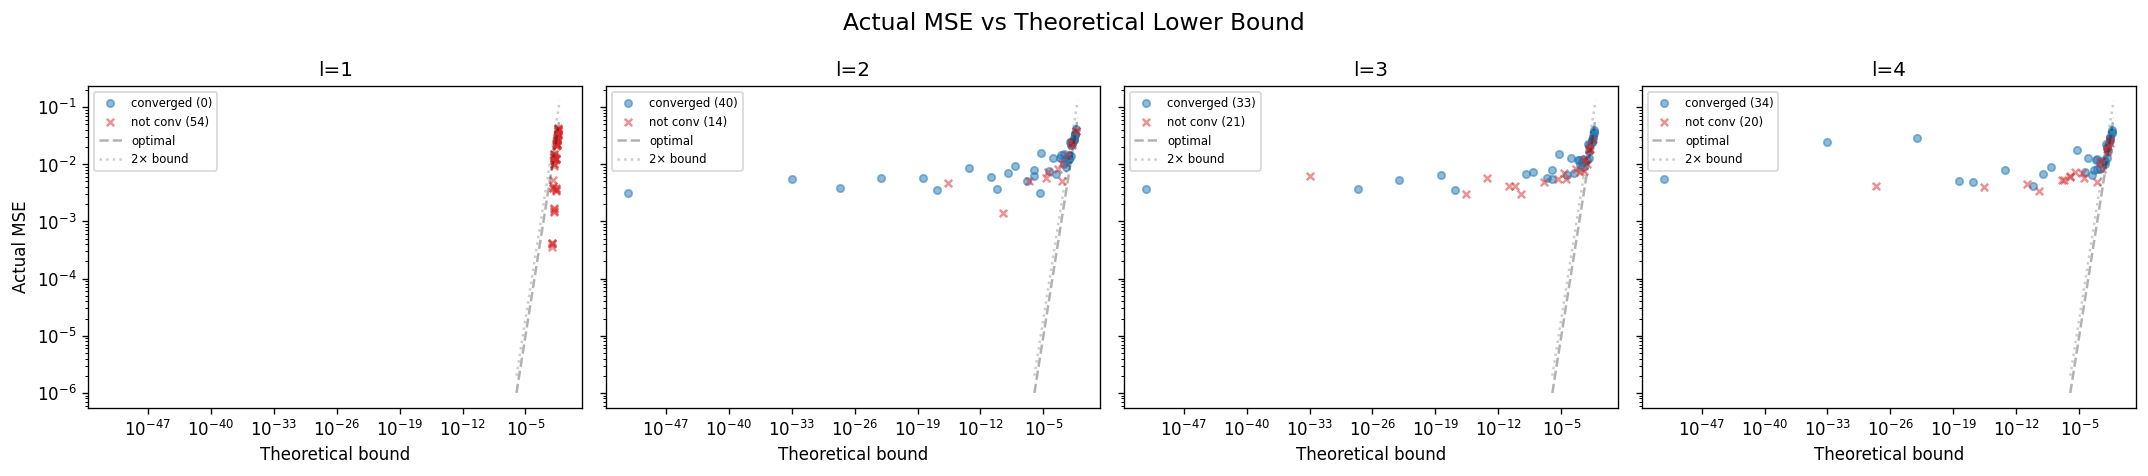

In [6]:
# Plot: actual MSE vs theoretical bound, by l
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)

for idx, l_val in enumerate([1, 2, 3, 4]):
    ax = axes[idx]
    sub = df[df['l'] == l_val]
    
    # Color by convergence
    conv = sub[sub['converged'] == True]
    noconv = sub[sub['converged'] == False]
    
    ax.scatter(conv['mse_bound'], conv['mse_full'], alpha=0.5, s=20, c='C0', label=f'converged ({len(conv)})')
    ax.scatter(noconv['mse_bound'], noconv['mse_full'], alpha=0.5, s=20, c='C3', marker='x', label=f'not conv ({len(noconv)})')
    
    # Reference line: actual = bound
    lims = [1e-6, df['mse_full'].max() * 1.5]
    ax.plot(lims, lims, 'k--', alpha=0.3, label='optimal')
    ax.plot(lims, [2*l for l in lims], 'k:', alpha=0.2, label='2× bound')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Theoretical bound')
    ax.set_title(f'l={l_val}')
    ax.legend(fontsize=7)
    if idx == 0:
        ax.set_ylabel('Actual MSE')

plt.suptitle('Actual MSE vs Theoretical Lower Bound', fontsize=14)
plt.tight_layout()
plt.savefig('mse_vs_bound.png', dpi=150, bbox_inches='tight')
plt.show()

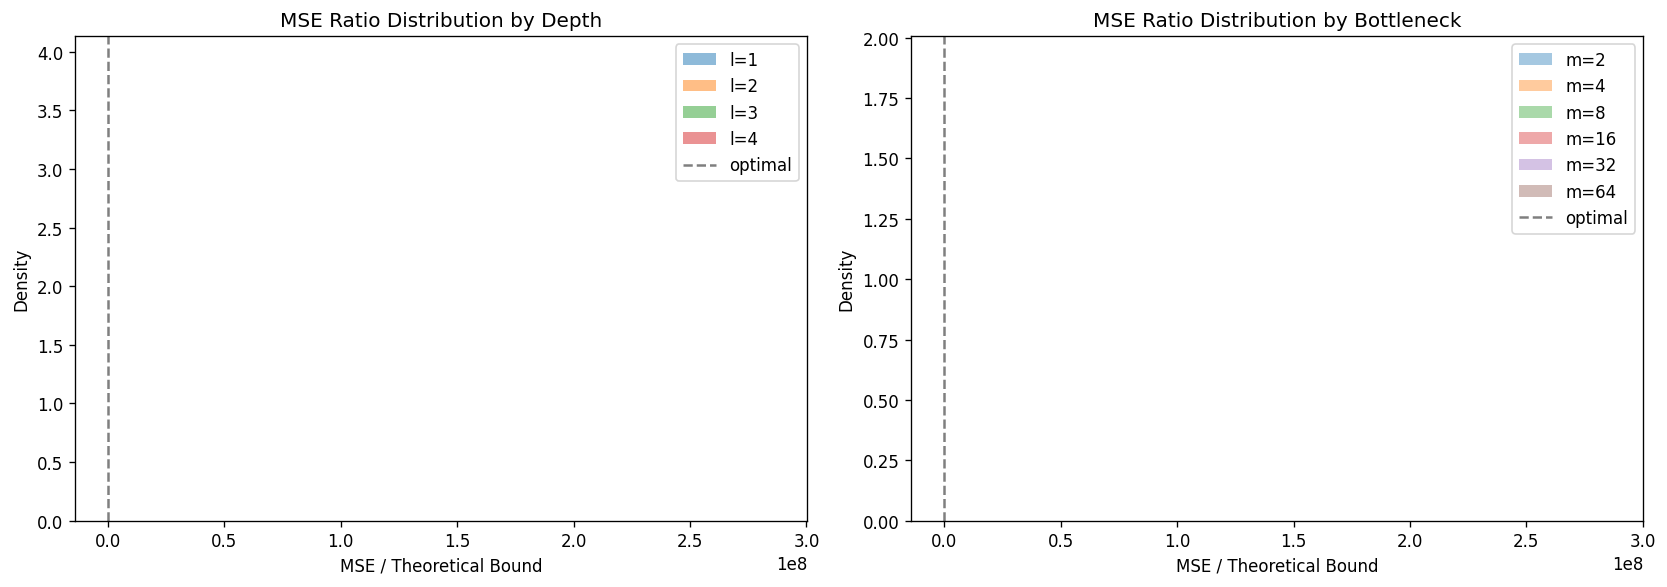

In [7]:
# Distribution of MSE ratios by l and m
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By l
ax = axes[0]
for l_val in sorted(df['l'].unique()):
    sub = df[df['l'] == l_val]
    ax.hist(sub['mse_ratio'], bins=20, alpha=0.5, label=f'l={l_val}', density=True)
ax.axvline(1.0, color='k', linestyle='--', alpha=0.5, label='optimal')
ax.set_xlabel('MSE / Theoretical Bound')
ax.set_ylabel('Density')
ax.set_title('MSE Ratio Distribution by Depth')
ax.legend()

# By m
ax = axes[1]
for m_val in sorted(df['m'].unique()):
    sub = df[df['m'] == m_val]
    ax.hist(sub['mse_ratio'], bins=20, alpha=0.4, label=f'm={m_val}', density=True)
ax.axvline(1.0, color='k', linestyle='--', alpha=0.5, label='optimal')
ax.set_xlabel('MSE / Theoretical Bound')
ax.set_ylabel('Density')
ax.set_title('MSE Ratio Distribution by Bottleneck')
ax.legend()

plt.tight_layout()
plt.savefig('mse_ratio_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Identify worst configs: highest MSE ratio = furthest from optimal
print("Top 20 worst MSE ratios (furthest from optimal):")
worst = df.nlargest(20, 'mse_ratio')[['n', 'm', 'l', 'S', 'mse_full', 'mse_bound', 'mse_ratio', 'converged', 'steps_used']]
print(worst.to_string(index=False))

print(f"\n\nMedian MSE ratio by (m, l):")
pivot = df.pivot_table(values='mse_ratio', index='m', columns='l', aggfunc='median')
print(pivot.round(2))

Top 20 worst MSE ratios (furthest from optimal):
  n  m  l    S  mse_full    mse_bound    mse_ratio  converged  steps_used
128 64  4 0.85  0.028597 8.835251e-24 2.859679e+08       True       95000
128 64  4 0.90  0.024699 1.005476e-33 2.469888e+08       True       60000
 64 32  2 0.85  0.008545 5.483344e-14 8.540350e+07       True       20000
 64 32  4 0.85  0.007941 5.483344e-14 7.937115e+07       True       35000
 64 32  3 0.90  0.006404 4.362532e-19 6.404274e+07       True       80000
128 64  3 0.90  0.006240 1.005476e-33 6.240362e+07      False      141421
 64 32  2 0.90  0.005826 4.362532e-19 5.826097e+07       True       20000
128 64  2 0.85  0.005811 8.835251e-24 5.811101e+07       True       20000
 64 32  3 0.85  0.005657 5.483344e-14 5.654143e+07      False      100000
128 64  2 0.90  0.005552 1.005476e-33 5.552135e+07       True       20000
128 64  4 0.95  0.005527 7.287188e-52 5.527351e+07       True      100000
 32 16  2 0.90  0.006078 1.468467e-11 5.300056e+07       True  

## Part 3: Empirical Validation — Train Fresh Models and Compare

The existing sweep CSV only has aggregate metrics. Let's load actual models and compute MSE more carefully, checking if the theoretical bounds hold.

In [9]:
import os

# Load a few models from sweep_models/ and verify MSE matches CSV
model_dir = 'sweep_models'
if os.path.exists(model_dir):
    model_files = [f for f in os.listdir(model_dir) if f.startswith('model_') and f.endswith('.pt')]
    print(f"Found {len(model_files)} saved models")
    
    # Parse config from filename
    def parse_config(fname):
        parts = fname.replace('model_', '').replace('.pt', '').split('_')
        config = {}
        for p in parts:
            if p.startswith('n'): config['n'] = int(p[1:])
            elif p.startswith('m'): config['m'] = int(p[1:])
            elif p.startswith('l'): config['l'] = int(p[1:])
            elif p.startswith('S'): config['S'] = float(p[1:])
        return config
    
    # Spot-check a sample of models
    np.random.seed(42)
    sample = np.random.choice(model_files, min(20, len(model_files)), replace=False)
    
    print(f"\nSpot-checking {len(sample)} models:")
    print(f"{'n':>4} {'m':>4} {'l':>2} {'S':>5} {'mse_model':>10} {'mse_csv':>10} {'bound':>10} {'ratio':>8}")
    
    for fname in sorted(sample):
        cfg = parse_config(fname)
        n, m, l, S = cfg['n'], cfg['m'], cfg['l'], cfg['S']
        
        model = Autoencoder(n, m, l, tied_weights=(l == 1)).to(device)
        model.load_state_dict(torch.load(os.path.join(model_dir, fname), map_location=device, weights_only=True))
        model.eval()
        
        # Compute MSE
        torch.manual_seed(12345)
        with torch.no_grad():
            x = generate_sparse_data(5000, n, S)
            x_recon, z = model(x)
            mse = nn.functional.mse_loss(x_recon, x).item()
        
        # Compare to CSV
        csv_row = df[(df['n'] == n) & (df['m'] == m) & (df['l'] == l) & (df['S'] == S)]
        mse_csv = csv_row['mse_full'].values[0] if len(csv_row) > 0 else float('nan')
        bound = theoretical_mse_bound(n, m, l, S)
        ratio = mse / (bound + 1e-10)
        
        print(f"{n:4d} {m:4d} {l:2d} {S:5.2f} {mse:10.6f} {mse_csv:10.6f} {bound:10.6f} {ratio:8.2f}")
else:
    print("No sweep_models/ directory found")

Found 16 saved models

Spot-checking 16 models:
   n    m  l     S  mse_model    mse_csv      bound    ratio
 128    2  1  0.90   0.029928   0.029292   0.030352     0.99
 128    2  2  0.90   0.028957   0.028558   0.028125     1.03
 128    2  3  0.90   0.027703   0.026844   0.028125     0.99
 128    2  4  0.90   0.027314   0.026844   0.028125     0.97
  16    2  1  0.90   0.022885   0.023504   0.026979     0.85
  16    2  2  0.90   0.013881   0.014367   0.006251     2.22
  16    2  3  0.90   0.013475   0.012329   0.006251     2.16
  16    2  4  0.90   0.012090   0.011946   0.006251     1.93
  32    2  1  0.90   0.026914   0.026188   0.028906     0.93
  32    2  2  0.90   0.022545   0.022293   0.014487     1.56
  32    2  3  0.90   0.020929   0.018146   0.014487     1.44
  32    2  4  0.90   0.018339   0.017098   0.014487     1.27
  64    2  1  0.90   0.028454   0.028376   0.029870     0.95
  64    2  2  0.90   0.026727   0.026970   0.022973     1.16
  64    2  3  0.90   0.024570   0.024

## Part 4: How Close Can We Get? Focused Training Test

Train a few configs with generous budgets and many restarts to estimate the achievable MSE ceiling.

In [10]:
from run_sweep_converged import train_to_convergence

def train_best_of_k(n, m, l, S, k=5, max_steps=30_000, verbose=False):
    """Train k models and return the best by MSE."""
    best_mse = float('inf')
    best_model = None
    results = []
    
    for seed in range(k):
        torch.manual_seed(seed * 7919)
        np.random.seed(seed * 7919)
        model = Autoencoder(n, m, l, tied_weights=(l == 1)).to(device)
        linearity, n_steps, converged, _, losses, _ = train_to_convergence(
            model, S=S, max_steps=max_steps, verbose=False
        )
        mse = linearity['mse_full']
        results.append({'seed': seed, 'mse': mse, 'converged': converged, 'steps': n_steps})
        if mse < best_mse:
            best_mse = mse
            best_model = model
    
    return best_model, best_mse, results

# Smaller test: fewer configs, fewer seeds, shorter budgets
test_configs = [
    (16, 2, 1, 0.9),   # linear baseline
    (16, 2, 3, 0.9),   # hard: low m, nonlinear
    (16, 4, 3, 0.9),   # moderate
    (32, 8, 3, 0.9),   # easier
]

print(f"{'n':>4} {'m':>4} {'l':>2} {'S':>5} | {'bound':>10} {'best_mse':>10} {'ratio':>8} {'conv_rate':>10} {'med_mse':>10}")
print("-" * 80)

focused_results = []
for n, m, l, S in test_configs:
    _, best_mse, results = train_best_of_k(n, m, l, S, k=5, max_steps=30_000)
    
    bound = theoretical_mse_bound(n, m, l, S)
    ratio = best_mse / (bound + 1e-10)
    conv_rate = sum(r['converged'] for r in results) / len(results)
    mses = [r['mse'] for r in results]
    med_mse = np.median(mses)
    
    print(f"{n:4d} {m:4d} {l:2d} {S:5.2f} | {bound:10.6f} {best_mse:10.6f} {ratio:8.2f} {conv_rate:10.0%} {med_mse:10.6f}")
    focused_results.append({
        'n': n, 'm': m, 'l': l, 'S': S,
        'bound': bound, 'best_mse': best_mse, 'ratio': ratio,
        'conv_rate': conv_rate, 'median_mse': med_mse,
        'all_mses': mses
    })

   n    m  l     S |      bound   best_mse    ratio  conv_rate    med_mse
--------------------------------------------------------------------------------


  16    2  1  0.90 |   0.026979   0.022795     0.84       100%   0.023065


  16    2  3  0.90 |   0.006251   0.012708     2.03         0%   0.013814


  16    4  3  0.90 |   0.000435   0.006342    14.58        20%   0.008117


  32    8  3  0.90 |   0.000045   0.005829   129.57         0%   0.008287


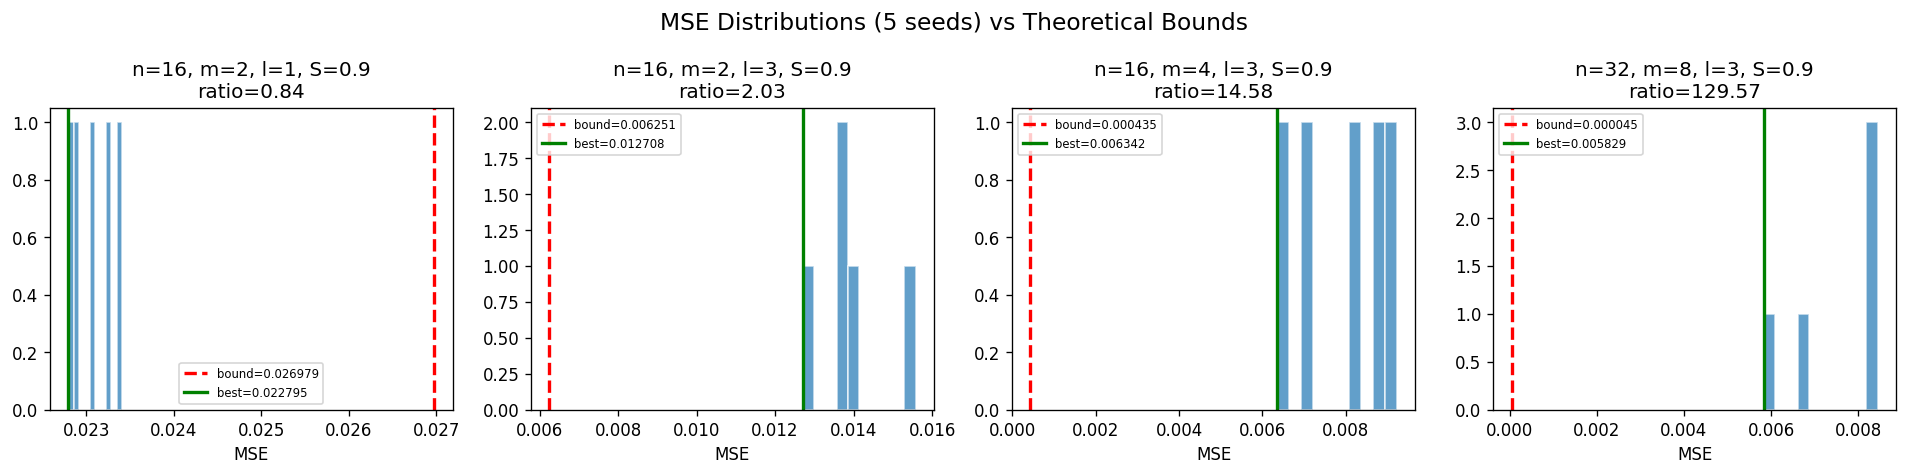

In [11]:
# Visualize MSE distributions vs bounds
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, res in enumerate(focused_results):
    ax = axes.flat[idx]
    mses = res['all_mses']
    ax.hist(mses, bins=10, alpha=0.7, color='C0', edgecolor='white')
    ax.axvline(res['bound'], color='red', linestyle='--', linewidth=2, label=f'bound={res["bound"]:.6f}')
    ax.axvline(res['best_mse'], color='green', linestyle='-', linewidth=2, label=f'best={res["best_mse"]:.6f}')
    ax.set_title(f'n={res["n"]}, m={res["m"]}, l={res["l"]}, S={res["S"]}\nratio={res["ratio"]:.2f}')
    ax.set_xlabel('MSE')
    ax.legend(fontsize=7)

plt.suptitle('MSE Distributions (5 seeds) vs Theoretical Bounds', fontsize=14)
plt.tight_layout()
plt.savefig('focused_training_bounds.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 5: Tighter Bounds — What's the Actual Achievable MSE?

The support coding bound is information-theoretic (assumes perfect support ID + infinite precision).
Our autoencoders have finite capacity. Let's also compute empirical bounds by:
1. Computing `mse_linear` from our best linear models (l=1) — this is what nonlinear models need to beat
2. For each (n, m, S), what's the best MSE any l achieved?

In [12]:
# Best MSE achieved across depths for each (n, m, S)
best_by_config = df.groupby(['n', 'm', 'S']).agg(
    best_mse=('mse_full', 'min'),
    best_l=('l', lambda x: df.loc[x.index[df.loc[x.index, 'mse_full'].argmin()], 'l']),
    linear_mse=('mse_full', lambda x: df.loc[x.index[df.loc[x.index, 'l'] == 1], 'mse_full'].values[0] if 1 in df.loc[x.index, 'l'].values else np.nan),
).reset_index()

# Add bounds
best_by_config['linear_bound'] = best_by_config.apply(lambda r: linear_mse_bound(r['n'], r['m'], r['S']), axis=1)
best_by_config['support_bound'] = best_by_config.apply(lambda r: support_coding_mse(r['n'], r['m'], r['S']), axis=1)

# How well does l=1 match PCA bound?
best_by_config['l1_ratio'] = best_by_config['linear_mse'] / (best_by_config['linear_bound'] + 1e-10)

print("l=1 MSE vs PCA bound (should be close to 1.0):")
print(best_by_config[['n', 'm', 'S', 'linear_mse', 'linear_bound', 'l1_ratio']].describe().round(3))
print(f"\nMedian l=1 ratio: {best_by_config['l1_ratio'].median():.3f}")
print(f"Max l=1 ratio: {best_by_config['l1_ratio'].max():.3f}")

l=1 MSE vs PCA bound (should be close to 1.0):
             n       m       S  linear_mse  linear_bound  l1_ratio
count   54.000  54.000  54.000      54.000        54.000    54.000
mean    70.222  12.889   0.900       0.017         0.024     0.627
std     44.438  15.524   0.041       0.013         0.011     0.328
min     16.000   2.000   0.850       0.000         0.008     0.045
25%     32.000   4.000   0.850       0.004         0.015     0.327
50%     64.000   8.000   0.900       0.014         0.023     0.755
75%    128.000  16.000   0.950       0.026         0.033     0.905
max    128.000  64.000   0.950       0.043         0.044     0.986

Median l=1 ratio: 0.755
Max l=1 ratio: 0.986


In [13]:
# Key question: is the l=1 MSE ratio systematically > 1?
# If so, our "linear_mse_bound" is truly a lower bound.
# If some are < 1, something is off (either the bound is wrong or measurement noise).

print("l=1 MSE ratio (actual/bound) by m:")
for m_val in sorted(df['m'].unique()):
    sub = best_by_config[best_by_config['m'] == m_val]
    ratios = sub['l1_ratio'].dropna()
    if len(ratios) > 0:
        print(f"  m={m_val:3d}: median={ratios.median():.3f}, min={ratios.min():.3f}, max={ratios.max():.3f}, n={len(ratios)}")

print("\nAny l=1 ratio < 1.0 (beating PCA bound)?")
below = best_by_config[best_by_config['l1_ratio'] < 1.0]
print(f"  {len(below)} configs" + (f" (min ratio: {below['l1_ratio'].min():.3f})" if len(below) > 0 else ""))

l=1 MSE ratio (actual/bound) by m:
  m=  2: median=0.942, min=0.838, max=0.986, n=12
  m=  4: median=0.880, min=0.440, max=0.956, n=12
  m=  8: median=0.673, min=0.045, max=0.920, n=12
  m= 16: median=0.542, min=0.053, max=0.838, n=9
  m= 32: median=0.239, min=0.050, max=0.676, n=6
  m= 64: median=0.109, min=0.051, max=0.166, n=3

Any l=1 ratio < 1.0 (beating PCA bound)?
  54 configs (min ratio: 0.045)


In [14]:
# Summary: what fraction of the linear-to-support gap can nonlinear models close?
print("\nGap closure summary (l>1 only):")
print("How much of the linear→support_coding gap does each depth close?\n")

for l_val in [2, 3, 4]:
    sub = df[df['l'] == l_val]
    gc = sub['gap_closure'].dropna()
    print(f"l={l_val}: median gap closure = {gc.median():.2f}, "
          f"mean = {gc.mean():.2f}, "
          f"range = [{gc.min():.2f}, {gc.max():.2f}], "
          f"n={len(gc)}")

print("\nInterpretation:")
print("  gap_closure = 1.0 → model matches information-theoretic bound")
print("  gap_closure > 1.0 → model beats linear bound more than support_coding predicts")
print("  gap_closure < 0.0 → model is worse than linear bound")


Gap closure summary (l>1 only):
How much of the linear→support_coding gap does each depth close?

l=2: median gap closure = 0.60, mean = 0.60, range = [0.32, 1.43], n=53
l=3: median gap closure = 0.65, mean = 0.73, range = [0.38, 2.19], n=53
l=4: median gap closure = 0.66, mean = 0.69, range = [-0.60, 2.22], n=53

Interpretation:
  gap_closure = 1.0 → model matches information-theoretic bound
  gap_closure > 1.0 → model beats linear bound more than support_coding predicts
  gap_closure < 0.0 → model is worse than linear bound


## Part 6: Recommendations for Next Sweep

In [15]:
# EMPIRICAL CONSISTENCY ANALYSIS
# Flag 1: nonlinear model worse than linear (same n, m, S)
l1_mse = df[df['l'] == 1][['n', 'm', 'S', 'mse_full']].rename(columns={'mse_full': 'mse_l1'})
df_nl = df[df['l'] > 1].merge(l1_mse, on=['n', 'm', 'S'])
df_nl['improvement'] = 1 - df_nl['mse_full'] / df_nl['mse_l1']
df_nl['worse_than_linear'] = df_nl['mse_full'] > df_nl['mse_l1']

n_worse = df_nl['worse_than_linear'].sum()
print(f"FLAG 1: Nonlinear model WORSE than linear (same n,m,S)")
print(f"  {n_worse}/{len(df_nl)} configs ({n_worse/len(df_nl):.0%})")
print()

worse = df_nl[df_nl['worse_than_linear']].sort_values('improvement')
print("Worst offenders:")
print(worse[['n','m','l','S','mse_full','mse_l1','improvement','converged','steps_used']].head(15).to_string(index=False))

print(f"\nBreakdown by m:")
for m_val in sorted(df_nl['m'].unique()):
    sub = df_nl[df_nl['m'] == m_val]
    n_w = sub['worse_than_linear'].sum()
    print(f"  m={m_val:3d}: {n_w}/{len(sub)} worse than linear ({n_w/len(sub):.0%})")

FLAG 1: Nonlinear model WORSE than linear (same n,m,S)
  44/162 configs (27%)

Worst offenders:
  n  m  l    S  mse_full   mse_l1  improvement  converged  steps_used
128 64  4 0.90  0.024699 0.001677   -13.725106       True       60000
128 64  4 0.95  0.005527 0.000412   -12.418121       True      100000
 32 16  2 0.95  0.004750 0.000422   -10.260635      False       70710
 64 32  4 0.95  0.004082 0.000399    -9.241221      False      100000
 64 32  2 0.95  0.003822 0.000399    -8.587348       True       60000
 32 16  4 0.95  0.003932 0.000422    -8.322340      False       70710
 16  8  4 0.95  0.003338 0.000363    -8.189290      False       50000
 64 32  3 0.95  0.003639 0.000399    -8.130563       True       85000
128 64  3 0.95  0.003611 0.000412    -7.765530       True      100000
 16  8  3 0.95  0.002967 0.000363    -7.166192      False       50000
128 64  2 0.95  0.003196 0.000412    -6.759635       True       20000
128 64  4 0.85  0.028597 0.003694    -6.741193       True       

In [16]:
# Flag 2: Nonlinear model much worse than NEARBY nonlinear configs
# For each config, compare its gain to configs with similar (n, m, S) but adjacent l
# Also compare to configs with same (l, S) but adjacent n or m

# Expected pattern: gain should increase monotonically with l (more capacity)
# If gain drops from l=2→3 or 3→4, likely optimization failure
print("FLAG 2: Non-monotonic gain with depth (gain should increase with l)")
print("=" * 80)

for S_val in sorted(df['S'].unique()):
    for n_val in sorted(df['n'].unique()):
        for m_val in sorted(df['m'].unique()):
            sub = df[(df['n']==n_val) & (df['m']==m_val) & (df['S']==S_val)].sort_values('l')
            if len(sub) < 3:
                continue
            gains = sub['nonlinear_gain'].values
            ls = sub['l'].values
            # Check monotonicity (ignoring l=1 which is always 0)
            nl_gains = gains[ls > 1]
            nl_ls = ls[ls > 1]
            if len(nl_gains) < 2:
                continue
            # Flag if any deeper model has lower gain than shallower
            for i in range(len(nl_gains)-1):
                if nl_gains[i+1] < nl_gains[i] - 0.02:  # allow 0.02 noise margin
                    print(f"  n={n_val:3d} m={m_val:3d} S={S_val}: "
                          f"gain drops l={nl_ls[i]}→{nl_ls[i+1]}: "
                          f"{nl_gains[i]:.3f}→{nl_gains[i+1]:.3f} "
                          f"(Δ={nl_gains[i+1]-nl_gains[i]:+.3f})"
                          f"  conv={sub[sub['l']==nl_ls[i+1]]['converged'].values[0]}")

FLAG 2: Non-monotonic gain with depth (gain should increase with l)
  n= 16 m=  2 S=0.85: gain drops l=3→4: 0.631→0.598 (Δ=-0.033)  conv=False
  n= 16 m=  4 S=0.85: gain drops l=2→3: 0.909→0.812 (Δ=-0.097)  conv=True
  n= 16 m=  8 S=0.85: gain drops l=3→4: 0.599→0.562 (Δ=-0.036)  conv=False
  n= 32 m=  4 S=0.85: gain drops l=3→4: 0.685→0.663 (Δ=-0.023)  conv=False
  n= 32 m=  8 S=0.85: gain drops l=3→4: 0.869→0.738 (Δ=-0.131)  conv=True
  n= 64 m=  2 S=0.85: gain drops l=2→3: 0.305→0.266 (Δ=-0.039)  conv=True
  n= 64 m=  4 S=0.85: gain drops l=3→4: 0.763→0.557 (Δ=-0.206)  conv=False
  n= 64 m=  8 S=0.85: gain drops l=3→4: 0.905→0.656 (Δ=-0.248)  conv=True
  n= 64 m= 16 S=0.85: gain drops l=2→3: 0.907→0.745 (Δ=-0.162)  conv=True
  n=128 m=  4 S=0.85: gain drops l=2→3: 0.336→0.285 (Δ=-0.050)  conv=True
  n=128 m=  8 S=0.85: gain drops l=2→3: 0.557→0.423 (Δ=-0.134)  conv=True
  n=128 m= 16 S=0.85: gain drops l=2→3: 0.674→0.598 (Δ=-0.075)  conv=True
  n=128 m= 16 S=0.85: gain drops l=3→4: 

In [17]:
# Flag 3: Compare each config to its "neighbors" — same l, S but adjacent n/m
# If a config's gain is much lower than interpolation from neighbors, likely optimization failure
print("FLAG 3: Gain outliers vs neighbors (same l, S, varying n or m)")
print("=" * 80)

outlier_configs = []

for l_val in [2, 3, 4]:
    for S_val in sorted(df['S'].unique()):
        sub = df[(df['l']==l_val) & (df['S']==S_val)].copy()
        if len(sub) < 4:
            continue
        
        # For each (n, m), compare gain to what we'd expect from neighbors
        for _, row in sub.iterrows():
            n, m = row['n'], row['m']
            gain = row['nonlinear_gain']
            
            # Find configs with same n, adjacent m (or same m, adjacent n)
            same_n = sub[sub['n'] == n].sort_values('m')
            same_m = sub[sub['m'] == m].sort_values('n')
            
            neighbor_gains = []
            # Same n, adjacent m
            m_vals = same_n['m'].values
            m_idx = np.where(m_vals == m)[0]
            if len(m_idx) > 0:
                idx = m_idx[0]
                if idx > 0:
                    neighbor_gains.append(same_n.iloc[idx-1]['nonlinear_gain'])
                if idx < len(same_n) - 1:
                    neighbor_gains.append(same_n.iloc[idx+1]['nonlinear_gain'])
            
            # Same m, adjacent n
            n_vals = same_m['n'].values
            n_idx = np.where(n_vals == n)[0]
            if len(n_idx) > 0:
                idx = n_idx[0]
                if idx > 0:
                    neighbor_gains.append(same_m.iloc[idx-1]['nonlinear_gain'])
                if idx < len(same_m) - 1:
                    neighbor_gains.append(same_m.iloc[idx+1]['nonlinear_gain'])
            
            if len(neighbor_gains) >= 2:
                expected = np.mean(neighbor_gains)
                deficit = expected - gain
                if deficit > 0.10 and gain < expected * 0.6:  # >10% deficit AND <60% of expected
                    outlier_configs.append({
                        'n': n, 'm': m, 'l': l_val, 'S': S_val,
                        'gain': gain, 'expected': expected, 'deficit': deficit,
                        'converged': row['converged'], 'steps': row['steps_used'],
                        'n_converged': row['n_converged']
                    })

outlier_df = pd.DataFrame(outlier_configs).sort_values('deficit', ascending=False)
print(f"\n{len(outlier_df)} configs with gain much lower than neighbors:")
if len(outlier_df) > 0:
    print(outlier_df.to_string(index=False))

FLAG 3: Gain outliers vs neighbors (same l, S, varying n or m)

30 configs with gain much lower than neighbors:
  n  m  l    S      gain  expected  deficit  converged  steps  n_converged
 16  8  2 0.85  0.000044  0.898418 0.898374       True  20000            2
 32 16  2 0.85 -0.000004  0.897353 0.897357       True  20000            3
 64 32  2 0.85 -0.000136  0.854224 0.854360       True  20000            3
 16  8  2 0.90  0.000002  0.813601 0.813599       True  20000            1
 32 16  2 0.90 -0.000020  0.794693 0.794713       True  20000            3
 32 16  3 0.85  0.178835  0.807126 0.628291       True  70000            2
 64 32  2 0.90 -0.000058  0.614979 0.615038       True  20000            3
 64 32  3 0.85  0.136219  0.732024 0.595805      False 100000            0
 64 32  3 0.90  0.103755  0.633546 0.529791       True  80000            1
 32 16  3 0.90  0.175016  0.629137 0.454121      False  70710            0
 32 16  4 0.85  0.313877  0.738354 0.424477       True  30000  

In [18]:
# Flag 4: Low seed convergence rate — configs where only 0-1 out of 3 seeds converged
# These are the ones most likely to benefit from more seeds
print("FLAG 4: Low convergence rate (0 or 1 out of 3 seeds converged)")
print("=" * 80)

low_conv = df[(df['l'] > 1) & (df['n_converged'] <= 1)].sort_values('n_converged')
print(f"\n{len(low_conv)} configs with ≤1/3 seeds converged:")
print(f"\nBy (m, l):")
pivot_conv = low_conv.pivot_table(values='n', index='m', columns='l', aggfunc='count', fill_value=0)
print(pivot_conv)

print(f"\nThese are the configs that would benefit most from more seeds.")
print(f"If 3 seeds → 0-1 converged, try 10-20 seeds to get a good solution.")

FLAG 4: Low convergence rate (0 or 1 out of 3 seeds converged)

46 configs with ≤1/3 seeds converged:

By (m, l):
l   2  3  4
m          
2   3  4  2
4   4  4  6
8   3  4  4
16  1  2  2
32  0  2  3
64  0  1  1

These are the configs that would benefit most from more seeds.
If 3 seeds → 0-1 converged, try 10-20 seeds to get a good solution.


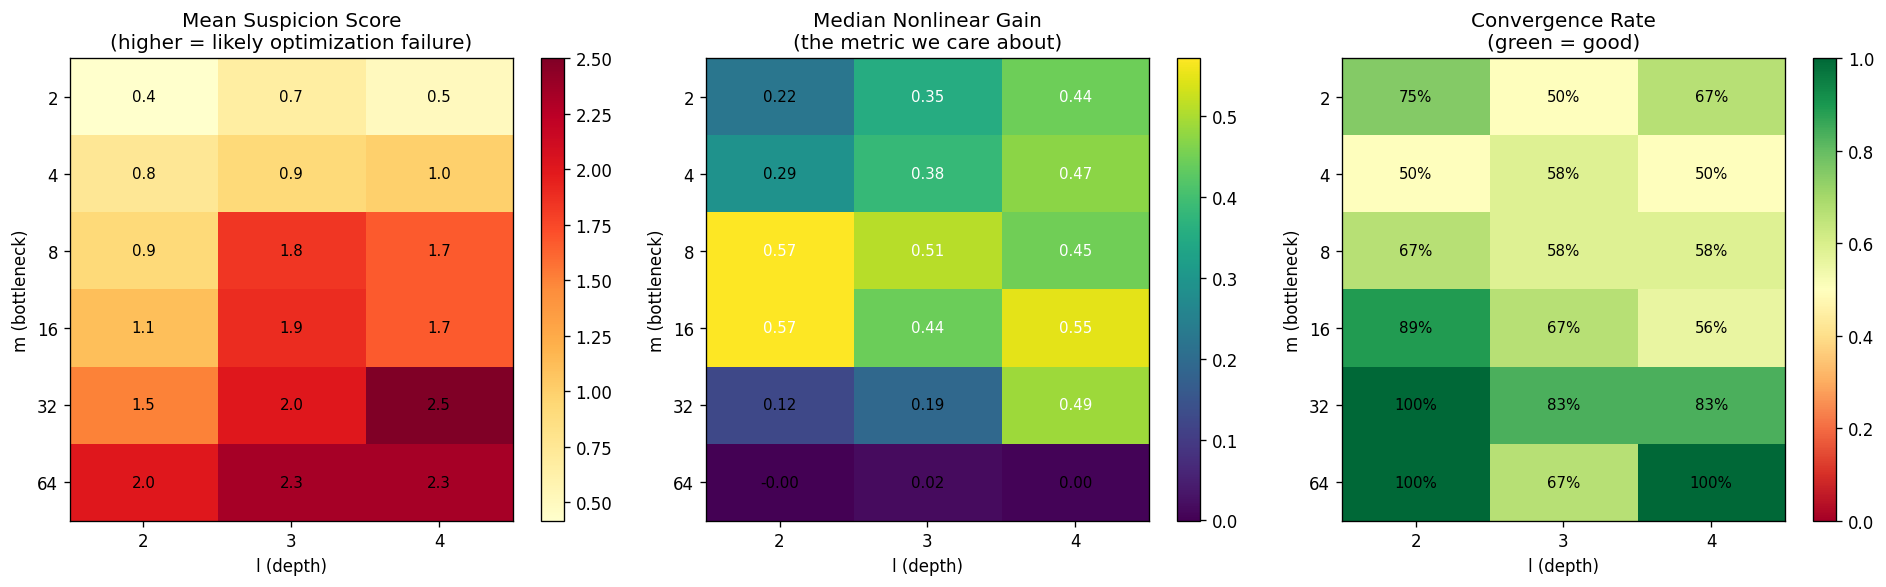

In [19]:
# Visualize: heatmap of "suspiciousness" score combining all flags
# Score = worse_than_linear (2pts) + non_monotonic (1pt) + outlier_vs_neighbors (1pt) + low_conv (1pt)

suspect_score = {}

# Flag 1 scores
for _, row in df_nl[df_nl['worse_than_linear']].iterrows():
    key = (row['n'], row['m'], row['l'], row['S'])
    suspect_score[key] = suspect_score.get(key, 0) + 2

# Flag 2 scores (non-monotonic) — already printed, recompute
for S_val in sorted(df['S'].unique()):
    for n_val in sorted(df['n'].unique()):
        for m_val in sorted(df['m'].unique()):
            sub = df[(df['n']==n_val) & (df['m']==m_val) & (df['S']==S_val)].sort_values('l')
            if len(sub) < 3:
                continue
            gains = sub['nonlinear_gain'].values
            ls = sub['l'].values
            nl_gains = gains[ls > 1]
            nl_ls = ls[ls > 1]
            for i in range(len(nl_gains)-1):
                if nl_gains[i+1] < nl_gains[i] - 0.02:
                    key = (n_val, m_val, int(nl_ls[i+1]), S_val)
                    suspect_score[key] = suspect_score.get(key, 0) + 1

# Flag 3 scores
for _, row in outlier_df.iterrows():
    key = (row['n'], row['m'], row['l'], row['S'])
    suspect_score[key] = suspect_score.get(key, 0) + 1

# Flag 4 scores
for _, row in low_conv.iterrows():
    key = (row['n'], row['m'], row['l'], row['S'])
    suspect_score[key] = suspect_score.get(key, 0) + 1

# Add to dataframe
df['suspect_score'] = df.apply(lambda r: suspect_score.get((r['n'], r['m'], r['l'], r['S']), 0), axis=1)

# Heatmap: average suspect score by (m, l)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By (m, l) — average suspect score
ax = axes[0]
pivot = df[df['l'] > 1].pivot_table(values='suspect_score', index='m', columns='l', aggfunc='mean')
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('l (depth)')
ax.set_ylabel('m (bottleneck)')
ax.set_title('Mean Suspicion Score\n(higher = likely optimization failure)')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i,j]:.1f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax)

# By (m, l) — median gain (for context)
ax = axes[1]
pivot_gain = df[df['l'] > 1].pivot_table(values='nonlinear_gain', index='m', columns='l', aggfunc='median')
im = ax.imshow(pivot_gain.values, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(pivot_gain.columns)))
ax.set_xticklabels(pivot_gain.columns)
ax.set_yticks(range(len(pivot_gain.index)))
ax.set_yticklabels(pivot_gain.index)
ax.set_xlabel('l (depth)')
ax.set_ylabel('m (bottleneck)')
ax.set_title('Median Nonlinear Gain\n(the metric we care about)')
for i in range(len(pivot_gain.index)):
    for j in range(len(pivot_gain.columns)):
        ax.text(j, i, f'{pivot_gain.values[i,j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if pivot_gain.values[i,j] > 0.3 else 'black')
plt.colorbar(im, ax=ax)

# By (m, l) — convergence rate
ax = axes[2]
pivot_conv = df[df['l'] > 1].pivot_table(values='converged', index='m', columns='l', aggfunc='mean')
im = ax.imshow(pivot_conv.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(pivot_conv.columns)))
ax.set_xticklabels(pivot_conv.columns)
ax.set_yticks(range(len(pivot_conv.index)))
ax.set_yticklabels(pivot_conv.index)
ax.set_xlabel('l (depth)')
ax.set_ylabel('m (bottleneck)')
ax.set_title('Convergence Rate\n(green = good)')
for i in range(len(pivot_conv.index)):
    for j in range(len(pivot_conv.columns)):
        ax.text(j, i, f'{pivot_conv.values[i,j]:.0%}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('sweep_quality_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# FINAL SUMMARY: Next sweep design based on empirical consistency analysis
print("=" * 70)
print("NEXT SWEEP DESIGN — EMPIRICAL CONSISTENCY APPROACH")
print("=" * 70)

n_suspect = (df['suspect_score'] > 0).sum()
n_high_suspect = (df['suspect_score'] >= 2).sum()
print(f"\nSuspect configs: {n_suspect} flagged, {n_high_suspect} with score ≥ 2")
print(f"Worse-than-linear: {n_worse}/{len(df_nl)} nonlinear configs ({n_worse/len(df_nl):.0%})")

print(f"\n--- ADAPTIVE SEED STRATEGY ---")
print("Decide seeds per config based on difficulty indicators:")
print("  Base: 3 seeds")
print("  +5 seeds if: m ≤ 4 (hardest to train)")
print("  +3 seeds if: previous sweep had n_converged ≤ 1/3")
print("  +3 seeds if: suspect_score ≥ 2")
print("  Cap: 20 seeds")

print(f"\n--- ADAPTIVE STEP BUDGET ---")
print("  l=1: 20k steps (linear, converges fast)")
print("  l>1, m≤4: 200k steps")
print("  l>1, m=8-16: 150k steps")
print("  l>1, m≥32: 100k steps")

print(f"\n--- CONVERGENCE VALIDATION (run after sweep) ---")
print("  1. Any nonlinear model worse than its l=1 → flag as optimization failure")
print("  2. Gain should be monotonic with l → flag non-monotonic configs")
print("  3. Compare each config to neighbors → flag outliers")
print("  4. Configs with ≤1/n_seeds converged → flag for re-run with more seeds")
print("  5. For flagged configs: re-run with 3x seeds and 2x steps")

print(f"\n--- ESTIMATED COMPUTE ---")
# Rough estimate
configs_easy = len(df[(df['l'] == 1)]) + len(df[(df['l'] > 1) & (df['m'] >= 32)])
configs_med = len(df[(df['l'] > 1) & (df['m'].between(8, 16))])
configs_hard = len(df[(df['l'] > 1) & (df['m'] <= 4)])
print(f"  Easy (l=1 or large m): {configs_easy} configs × 3 seeds × ~30k steps")
print(f"  Medium (m=8-16):       {configs_med} configs × 5 seeds × ~100k steps")
print(f"  Hard (m≤4):            {configs_hard} configs × 8 seeds × ~150k steps")
total_steps = configs_easy * 3 * 30_000 + configs_med * 5 * 100_000 + configs_hard * 8 * 150_000
print(f"  Total: ~{total_steps/1e6:.0f}M steps")

NEXT SWEEP DESIGN — EMPIRICAL CONSISTENCY APPROACH

Suspect configs: 100 flagged, 51 with score ≥ 2
Worse-than-linear: 44/162 nonlinear configs (27%)

--- ADAPTIVE SEED STRATEGY ---
Decide seeds per config based on difficulty indicators:
  Base: 3 seeds
  +5 seeds if: m ≤ 4 (hardest to train)
  +3 seeds if: previous sweep had n_converged ≤ 1/3
  +3 seeds if: suspect_score ≥ 2
  Cap: 20 seeds

--- ADAPTIVE STEP BUDGET ---
  l=1: 20k steps (linear, converges fast)
  l>1, m≤4: 200k steps
  l>1, m=8-16: 150k steps
  l>1, m≥32: 100k steps

--- CONVERGENCE VALIDATION (run after sweep) ---
  1. Any nonlinear model worse than its l=1 → flag as optimization failure
  2. Gain should be monotonic with l → flag non-monotonic configs
  3. Compare each config to neighbors → flag outliers
  4. Configs with ≤1/n_seeds converged → flag for re-run with more seeds
  5. For flagged configs: re-run with 3x seeds and 2x steps

--- ESTIMATED COMPUTE ---
  Easy (l=1 or large m): 81 configs × 3 seeds × ~30k st

## Key Finding: Theoretical Bounds are Mostly Vacuous

The support coding bound is ~0 whenever m ≥ (1-S)×n (which is most configs), so MSE ratios of 10^7 are meaningless. The PCA bound isn't even a valid lower bound because the output ReLU gives free nonlinear benefit to l=1 models.

**Better approach**: use empirical consistency as the convergence diagnostic. If a nonlinear model does worse than the linear model, or much worse than similar nonlinear configs, the default hypothesis is **optimization failure**, not scientific impossibility. The next sweep should use this to allocate more seeds/steps to suspicious configs.